<a href="https://colab.research.google.com/github/nam3user/comp_ling-course/blob/main/convnet_hw_done.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: бинарная классификация отзывов с помощью CNN

Применить CNN для анализа тональности текста (положительный/отрицательный отзыв)

Заполните пропущенный код (`### ВАШ КОД ЗДЕСЬ ###`). **Не меняйте структуру ячеек!** Все ответы и графики должны генерироваться автоматически

**Критерии проверки (максимум 10 баллов):**
*   **2 балла** — корректная загрузка и предобработка данных.
*   **3 балла** — корректно собранная модель по спецификации.
*   **2 балла** — успешное обучение модели (вывод истории обучения).
*   **3 балла** — оценка на тесте и выводы (accuracy > 0.85 даёт +1 балл).

---

## БЛОК 1: Загрузка данных

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.3VD96G_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.3VD96G_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.3VD96G_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
Тренировочные данные: 25000 samples
Тестовые данные: 25000 samples


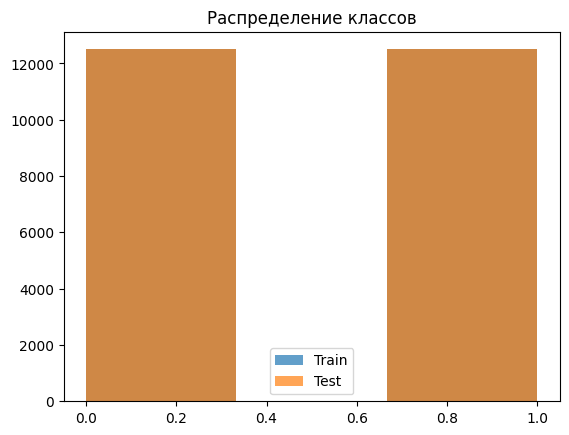

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds

# 1. Загрузите датасет IMDB Reviews (бинарная классификация)
### ВАШ КОД ЗДЕСЬ ###

train_ds, test_ds = tfds.load('imdb_reviews', split=['train', 'test'], as_supervised=True)

def ds_to_numpy(ds):
    texts, labels = [], []
    for text, label in tfds.as_numpy(ds):
        texts.append(text.decode('utf-8'))
        labels.append(label)
    return np.array(texts), np.array(labels)

x_train, y_train = ds_to_numpy(train_ds)
x_test, y_test = ds_to_numpy(test_ds)

# Используйте tfds.load('imdb_reviews', split=['train', 'test'], as_supervised=True)
# Преобразуйте данные в numpy массивы (x_train, y_train), (x_test, y_test)

print(f"Тренировочные данные: {len(x_train)} samples")
print(f"Тестовые данные: {len(x_test)} samples")

# 2. Визуализируйте распределение классов
plt.hist(y_train, bins=3, alpha=0.7, label='Train')
plt.hist(y_test, bins=3, alpha=0.7, label='Test')
plt.legend()
plt.title('Распределение классов')
plt.show()

## БЛОК 2: Предобработка текста

In [3]:
# 3. Создайте текстовый векторзатор (TextVectorization)
# Ограничьте словарь 10_000 самых частых слов, максимальную длину последовательности — 200 слов
### ВАШ КОД ЗДЕСЬ ###
# vectorizer = keras.layers.TextVectorization(max_tokens=..., output_sequence_length=...)
vectorizer = keras.layers.TextVectorization(
    max_tokens = 10000,
    output_mode = 'int',
    output_sequence_length = 200)

# 4. Адаптируйте векторзатор на тренировочных текстах
### ВАШ КОД ЗДЕСЬ ###

vectorizer.adapt(x_train)

# 5. Примените векторзацию к данным
x_train_vec = vectorizer(x_train).numpy()
x_test_vec = vectorizer(x_test).numpy()

print(f"Размерность после векторизации: {x_train_vec.shape}")

Размерность после векторизации: (25000, 200)


## БЛОК 3: Построение модели

In [4]:
# 6. Постройте модель CNN для текста СТРОГО ПО СПЕЦИФИКАЦИИ:
#    - Вход: векторная последовательность (200,)
#    - Embedding: размерность 128, входной словарь 10_000
#    - Conv1D: 64 фильтра, размер ядра 5, активация 'relu'
#    - GlobalMaxPooling1D
#    - Dense: 32 нейрона, 'relu'
#    - Dense: 1 нейрон, 'sigmoid' (бинарная классификация)
### ВАШ КОД ЗДЕСЬ ###
# model = keras.Sequential([...])

model = keras.Sequential([
    keras.layers.Input((200,)),
    keras.layers.Embedding(10000, 128),
    keras.layers.Conv1D(64, 5, activation='relu'),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dense(32, 'relu'),
    keras.layers.Dense(1, 'sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,137 (5.05 MB)

 Trainable params: 1,323,137 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

## БЛОК 4: Обучение

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 68ms/step - Precision: 0.6693 - Recall: 0.7181 - accuracy: 0.6812 - loss: 0.5658 - val_Precision: 0.8068 - val_Recall: 0.9139 - val_accuracy: 0.8456 - val_loss: 0.3498
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 74ms/step - Precision: 0.9158 - Recall: 0.9215 - accuracy: 0.9184 - loss: 0.2152 - val_Precision: 0.8836 - val_Recall: 0.8550 - val_accuracy: 0.8696 - val_loss: 0.3201
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - Precision: 0.9875 - Recall: 0.9886 - accuracy: 0.9882 - loss: 0.0568 - val_Precision: 0.8970 - val_Recall: 0.8226 - val_accuracy: 0.8624 - val_loss: 0.4038
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - Precision: 0.9991 - Recall: 0.9993 - accuracy: 0.9993 - loss: 0.0095 - val_Precision: 0.8632 - val_Recall: 0.8775 - val_accuracy: 0.8676 - val_loss: 0.4602
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0012 - val_Precision: 0.8671 - val_Re

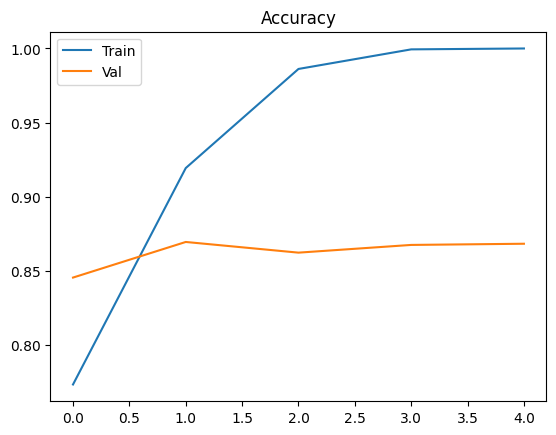

In [5]:
# 7. Скомпилируйте модель с оптимизатором 'adam', функцией потерь 'binary_crossentropy',
#    метриками ['accuracy', 'Precision', 'Recall']
### ВАШ КОД ЗДЕСЬ ###
# model.compile(...)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', 'Precision', 'Recall'])

# 8. Обучите модель на 5 эпох с validation_split=0.2, batch_size=32
### ВАШ КОД ЗДЕСЬ ###
# history = model.fit(...)

history = model.fit(x_train_vec, y_train,
                    epochs=5,
                    validation_split=0.2,
                    batch_size=32)

# 9. Постройте график точности (accuracy) на обучении и валидации
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()

## БЛОК 5: Оценка

In [9]:
# 10. Оцените модель на тестовых данных
### ВАШ КОД ЗДЕСЬ ###
# test_loss, test_acc, test_prec, test_rec = model.evaluate(...)

test_loss, test_acc, test_prec, test_rec = model.evaluate(x_test_vec, y_test)

print(f"Тестовая accuracy: {test_acc:.4f}")
print(f"Тестовая precision: {test_prec:.4f}")
print(f"Тестовая recall: {test_rec:.4f}")

# 11. Сделайте предсказания на первых 10 тестовых отзывах
#     и выведите: текст отзыва, истинный класс, предсказанный класс, вероятность
for i in range(10):
    text = x_test[i]
    true_label = "POS" if y_test[i] == 1 else "NEG"
    ### ВАШ КОД ЗДЕСЬ ###
    # pred_prob = model.predict(...)
    # pred_label = "POS" if pred_prob > 0.5 else "NEG"

    pred_prob = model.predict(x_test_vec[i:i+1])[0][0]
    pred_label = "POS" if pred_prob > 0.5 else "NEG"

    print(f"{text[:50]}... | True: {true_label} | Pred: {pred_label} ({pred_prob:.2f})")

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - Precision: 0.8641 - Recall: 0.8542 - accuracy: 0.8605 - loss: 0.5069
Тестовая accuracy: 0.8612
Тестовая precision: 0.8668
Тестовая recall: 0.8535
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
There are films that make careers. For George Rome... | True: POS | Pred: POS (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
A blackly comic tale of a down-trodden priest, Naz... | True: POS | Pred: POS (0.96)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Scary Movie 1-4, Epic Movie, Date Movie, Meet the ... | True: NEG | Pred: NEG (0.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Poor Shirley MacLaine tries hard to lend some grav... | True: NEG | Pred: NEG (0.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
As a former Erasmus student I enjoyed this film ve... | True: POS | Pred: POS (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
My God, Ryan Gosling has made a lot of deep charac... | True: POS | Pred: POS (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
This film just won the best film 

## БЛОК 6: Выводы

**Ответьте на вопросы в этой ячейке (текстом):**

1.  Какая итоговая точность (accuracy) на тесте?
2.  Что показывает разница между точностью на обучении и валидации? Есть ли переобучение?
3.  Какой из 10 показанных отзывов был классифицирован неверно? Почему, на ваш взгляд?

**Мои ответы:**
1.  Точность на тесте равна 0.8612
2.  Разница между точностью на обучении и валидации показывает, произошло ли переобучение. Если точность на обучении продолжает расти, а точность на валидации останавливается или начинает падать, то переобучение есть. Мне кажется, что переобучение произошло. На графике accuracy видно, что на обучении точность стремительно растет и достигает 100% (первый тревожный звоночек), а на валидации точность держится на 0.85. В итоге между двумя показателями возникает большой разрыв. Все это указывает на переобучение.
3.  Последний отзыв был неверно классифицирован. Я не уверена, почему именно, но, возможно, это связано с тем, как используются отрицательные конструкции в тексте. Например, само по себе "I wasn't really expecting much" выражает отрицательное отношение к фильму, но с добавлением "I couldn't' have been more wrong" смысл меняется на положительный. Само предложение "I couldn't' have been more wrong" - это двойное отрицание. Возможно, в обущающих данных мало примеров двойного отрицания и поэтому модель не смогла его корректно определить и понять, что отзыв положительный.